In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Leitura e Conhecimento dos dados

In [134]:
df = pd.read_csv("C:\\Users\\tatianayoko\\Documents\\YURI\\Projetos Dados\\star_classification.csv", dtype={'obj_ID': object})

print(df.head())

                obj_ID       alpha      delta         u         g         r  \
0  1237660961327743232  135.689107  32.494632  23.87882  22.27530  20.39501   
1  1237664879951151360  144.826101  31.274185  24.77759  22.83188  22.58444   
2  1237660961330430208  142.188790  35.582444  25.26307  22.66389  20.60976   
3  1237663478724297984  338.741038  -0.402828  22.13682  23.77656  21.61162   
4  1237680272041378048  345.282593  21.183866  19.43718  17.58028  16.49747   

          i         z  run_ID  rerun_ID  cam_col  field_ID   spec_obj_ID  \
0  19.16573  18.79371    3606       301        2        79  6.543777e+18   
1  21.16812  21.61427    4518       301        5       119  1.176014e+19   
2  19.34857  18.94827    3606       301        2       120  5.152200e+18   
3  20.50454  19.25010    4192       301        3       214  1.030107e+19   
4  15.97711  15.54461    8102       301        3       137  6.891865e+18   

    class  redshift  plate    MJD  fiber_ID  
0  GALAXY  0.634794   

In [73]:
#Para a construção do nosso modelo, o que precisamos:

    #1- Verificar balanceamento da variável 'class'.
    #2- Tratar nulos e valores inconsistentes.
    #3- Remover colunas de irrelevantes.
    #4- Explorar distribuições de u, g, r, i, z, redshift por classe.
    #5- Checar correlações entre filtros (u, g, r, i, z,).
    #6- Verificar objetos faltantes.
    #7- Garantir que não há data leakage (mesmo objeto em treino e teste).

In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  object 
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(9), int64(7), 

In [75]:
df.describe()

,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [76]:
class_unique = df['class'].unique()
class_unique

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [77]:
obj_ID_unique = df['obj_ID'].nunique()
obj_ID_unique

80846

In [78]:
spec_obj_ID_unique = df['spec_obj_ID'].nunique()
spec_obj_ID_unique

100000

In [79]:
# Parece que tem dados duplicados na coluna "obj_ID", coluna que deveria ter valores únicos

In [80]:
# Contagem da frequência de cada ID no df original
contagem_ids = df['obj_ID'].value_counts()

# Filtragem para manter apenas os IDs que apareceram mais de uma vez (as duplicatas)
ids_repetidos = contagem_ids[contagem_ids > 1]

print("\nIDs que foram repetidos e o número de vezes que apareceram:")
print(ids_repetidos)


IDs que foram repetidos e o número de vezes que apareceram:
1.237659326031e+18     17
1237663785277063424    11
1237666301627465984    11
1.237663462605e+18     11
1237666339727540480    11
                       ..
1237670965384904704     2
1237663462605193984     2
1237678889593864704     2
1237650371551822336     2
1237658423023174144     2
Name: obj_ID, Length: 14029, dtype: int64


In [81]:
# Busca de um valor que está repetido para análise
valor_procurado_float = '1237670965384904704'
df_filtrado_float = df[df['obj_ID'] == valor_procurado_float]
print(df_filtrado_float)

                    obj_ID       alpha      delta         u         g  \
7543   1237670965384904704  138.663421  14.286622  22.57331  20.33097   
36265  1237670965384904704  138.573219  14.169115  24.16176  21.28004   

              r         i         z  run_ID  rerun_ID  cam_col  field_ID  \
7543   18.69426  17.98580  17.61882    5935       301        4       149   
36265  20.85047  20.45592  20.19944    5935       301        4       149   

        spec_obj_ID   class  redshift  plate    MJD  fiber_ID  
7543   2.744994e+18  GALAXY  0.309250   2438  54056       182  
36265  5.970841e+18    STAR  0.000028   5303  55980       704  


In [82]:
# Temos um valor que se repete na coluna 'obj_ID' mas com valores diferentes nas outras colunas.

# 'obj_ID' é basicamente o "RG" ou "CPF" do objeto celeste (estrela, galáxia, quasar, etc.) na sua posição original no céu. 

# Assim, apesar de ser o mesmo objeto físico (obj_ID), os dados de espectroscopia que foram usados para classificar 
# o objeto eram diferentes ('spec_obj_IDs' diferentes), e por isso geraram classificações diferentes.

# A explicação mais provável é que o objeto detectado na imagem (obj_ID) é, na verdade, 
# dois objetos muito próximos no céu, mas que apareceram como um único ponto de luz nas imagens de fotometria 
# (que têm resolução mais baixa).

In [83]:
# De qualquer forma, iremos eliminar as possíveis linhas duplicadas
pré_drop = df.shape[0]
df = df.drop_duplicates()
pós_drop = df.shape [0]
print ('O número de linhas antes de tratamento de duplicada é:', pré_drop)
print ('Após o tratamento, o n° de linhas é:', pós_drop)

O número de linhas antes de tratamento de duplicada é: 100000
Após o tratamento, o n° de linhas é: 100000


In [84]:
     #1- Verificar balanceamento da variável 'class'.
# Nossos dados de classes estão desbalanceados, nesse caso, pode ser que o modelo que construirmos aprenda a chutar a classe majoritária e ainda sim, tenha uma "boa acurácia".
# Portanto, para o treinamento iremos utilizar Class Weights afim de "punir" erros nas classes de menor ocorrência.

    #2- Remover colunas de irrelevantes.
# Embora as colunas de identificação (obj_ID e spec_obj_ID) não sejam úteis para o treinamento do modelo, serão úteis para sua validação

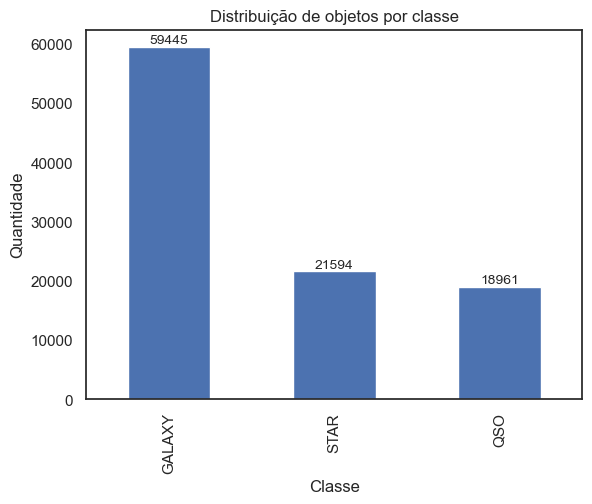

In [85]:
dist_class = df["class"].value_counts()

ax = dist_class.plot(
    kind = "bar",
    title = "Distribuição de objetos por classe",
    xlabel = "Classe",
    ylabel = "Quantidade")

for i, value in enumerate(dist_class):
    ax.text(i, value + (0.01 * max(dist_class)), str(value), ha="center", fontsize =10)
plt.show ()

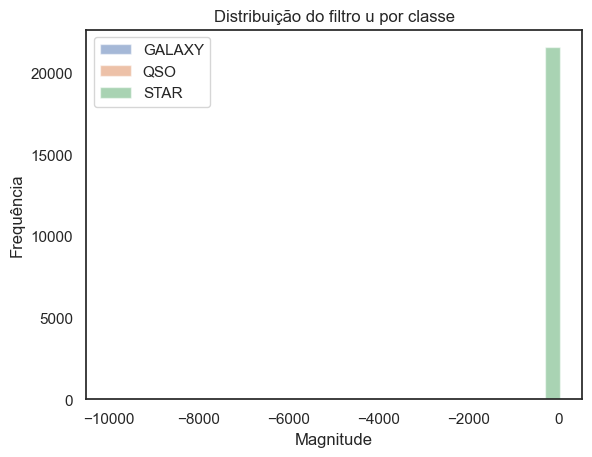

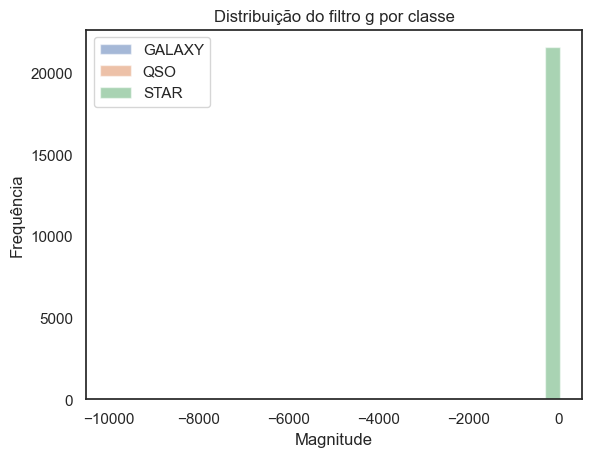

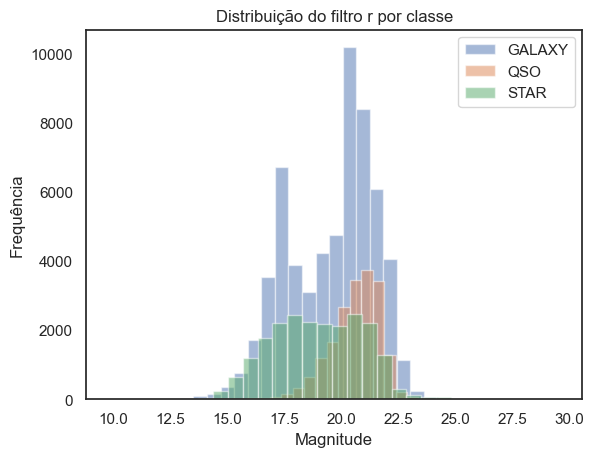

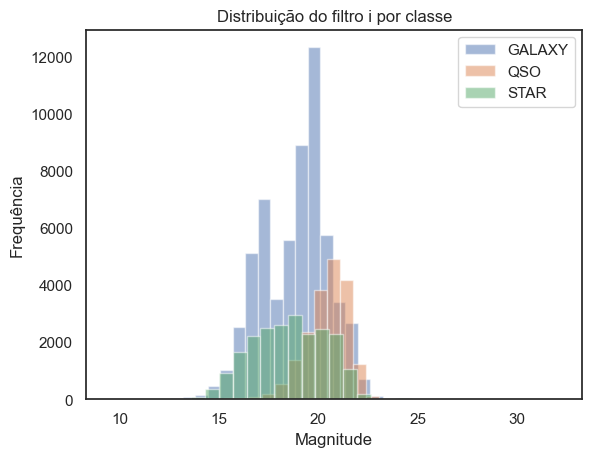

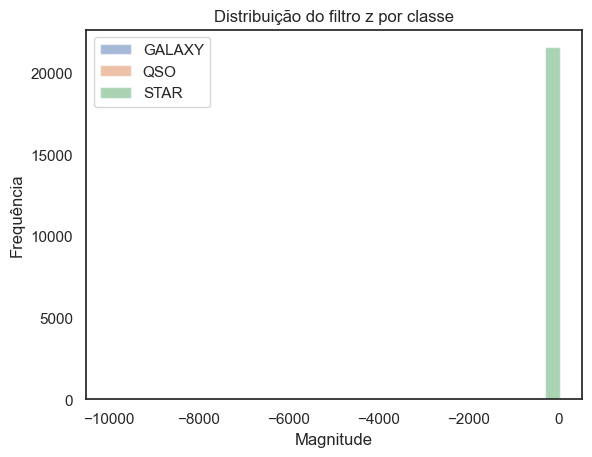

In [86]:
# vamos entender como os filtros fotométricos (u, g, r, i, z) se distribuem entre as classes 
filtros = ["u", "g", "r", "i", "z"]
classes = df["class"].unique()

for filtro in filtros:
    plt.figure()
    
    for classe in classes:
        subset = df[df["class"] == classe]
        plt.hist(subset[filtro],  bins=30, alpha=0.5, label=classe)
        
    plt.title(f"Distribuição do filtro {filtro} por classe")
    plt.xlabel("Magnitude")
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

In [87]:
df["u"].min()
df["u"].value_counts().head()

24.63465    77
24.63466    64
24.63467    44
24.63464    23
24.63468    20
Name: u, dtype: int64

In [88]:
df["u"].min()
df["u"].max()

32.78139

In [89]:
print(df["u"].describe())


count    100000.000000
mean         21.980468
std          31.769291
min       -9999.000000
25%          20.352353
50%          22.179135
75%          23.687440
max          32.781390
Name: u, dtype: float64


In [90]:
# Havia entendido que o gráfico estava errado devido o eixo X ir de -10000 até próximo de 0, tendo uma
# barra extremamente concentrada perto de 0.

# No entanto, o gráfico estava certo pois estava denunciando um problema,
# o "min -9999.000000" denuncia que o histograma está sendo dominado por valores artificiais,
# ocorre quando há alguma falha ou medição inexistente..

In [91]:
# Vamos alterar e limpar esses valores do nosso dataset
filtros = ["u", "g", "r", "i", "z"]

for col in filtros:
    df[col] = df[col].replace(-9999, np.nan)

df = df.dropna(subset=filtros)
df.describe()

,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.000000,99999.0,99999.000000,99999.000000,9.999900e+04,99999.000000,99999.000000,99999.000000,99999.000000
mean,177.628653,24.135552,22.080679,20.631583,19.645777,19.084865,18.768988,4481.403354,301.0,3.511625,186.127011,5.783903e+18,0.576667,5137.027890,55588.653687,449.315613
std,96.502612,19.644608,2.251068,2.037384,1.854763,1.757900,1.765982,1964.739021,0.0,1.586913,149.007687,3.324026e+18,0.730709,2952.312485,1808.492217,272.498252
min,0.005528,-18.785328,10.996230,10.498200,9.822070,9.469903,9.612333,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,127.517698,5.147477,20.352410,18.965240,18.135795,17.732280,17.460830,3187.000000,301.0,2.000000,82.000000,2.844137e+18,0.054522,2526.000000,54234.000000,221.000000
50%,180.900527,23.646462,22.179140,21.099930,20.125310,19.405150,19.004600,4188.000000,301.0,4.000000,146.000000,5.614896e+18,0.424176,4987.000000,55869.000000,433.000000
75%,233.895005,39.901582,23.687480,22.123775,21.044790,20.396510,19.921120,5326.000000,301.0,5.000000,241.000000,8.332365e+18,0.704172,7400.500000,56777.000000,645.000000
max,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


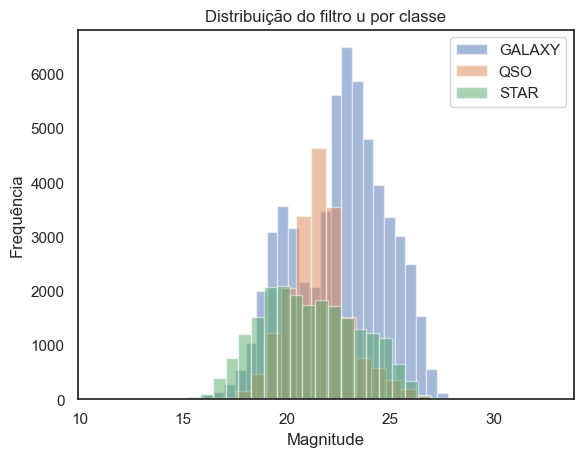

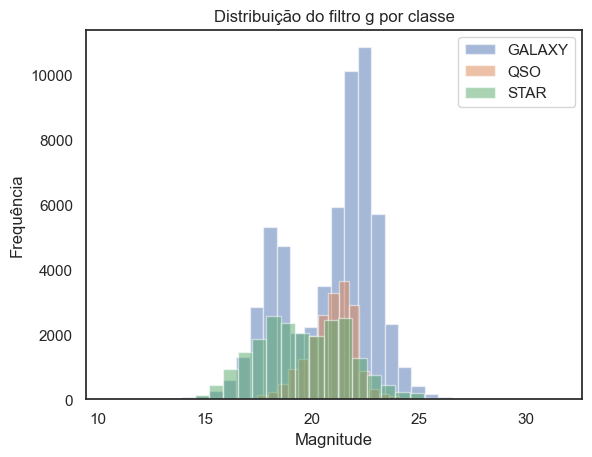

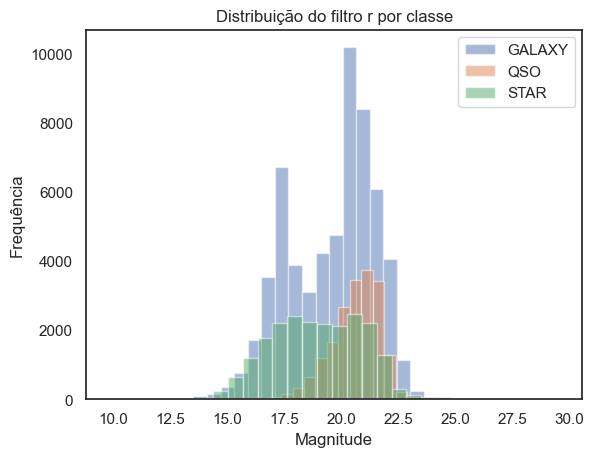

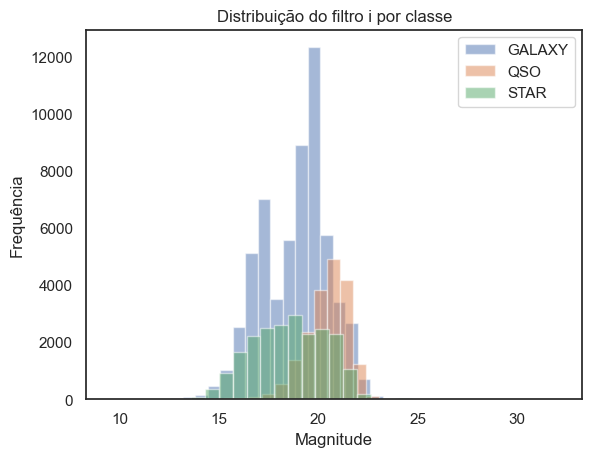

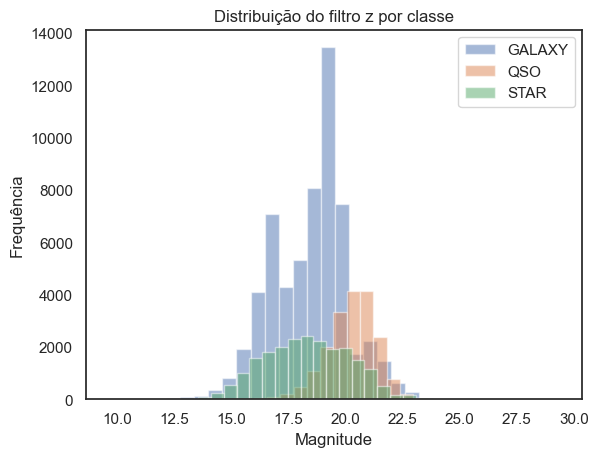

In [92]:
#retornando..
filtros = ["u", "g", "r", "i", "z"]
classes = df["class"].unique()

for filtro in filtros:
    plt.figure()
    
    for classe in classes:
        subset = df[df["class"] == classe]
        plt.hist(subset[filtro],  bins=30, alpha=0.5, label=classe)
        
    plt.title(f"Distribuição do filtro {filtro} por classe")
    plt.xlabel("Magnitude")
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

In [93]:
# Pelo gráfico:

# GALAXY parece concentrada em magnitudes maiores (~22–24)
# STAR parece mais deslocada para magnitudes menores (~18–22)
# QSO fica no meio

# Magnitude maior → objeto mais fraco. Então isso sugere:

# Estrelas tendem a ser mais brilhantes
# Galáxias tendem a ser mais fracas
# Quasares ficam intermediários

# A frequência absoluta está misturando a diferença real de distribuição e diferença de tamanho de classe
# Para comparar a forma real das distribuições usaremos a densidade

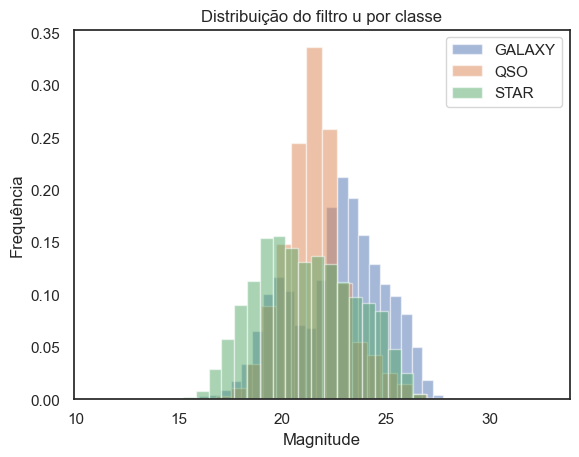

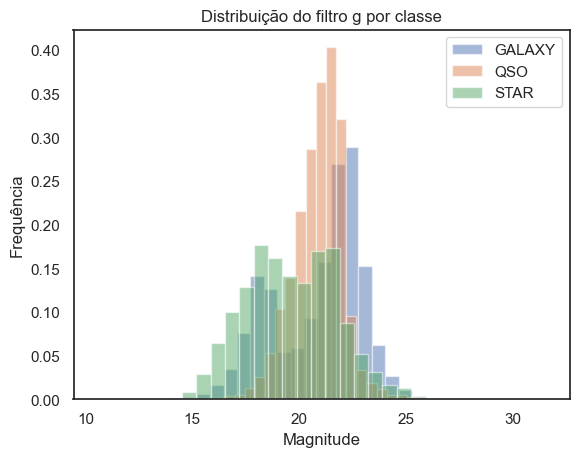

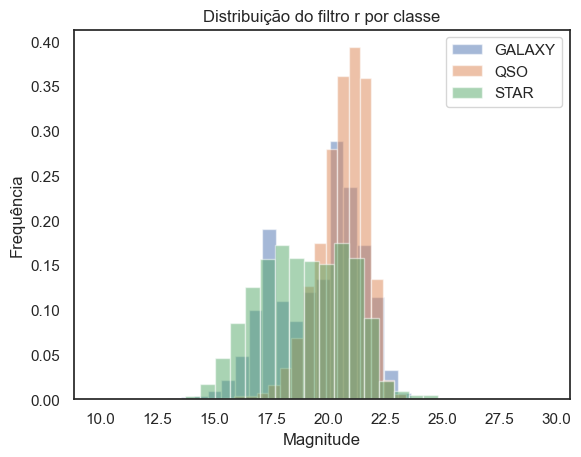

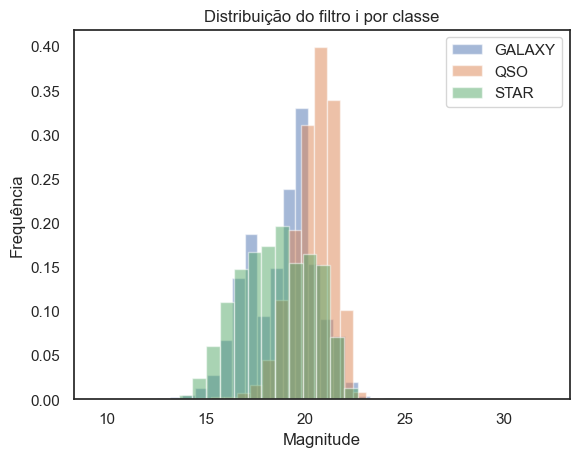

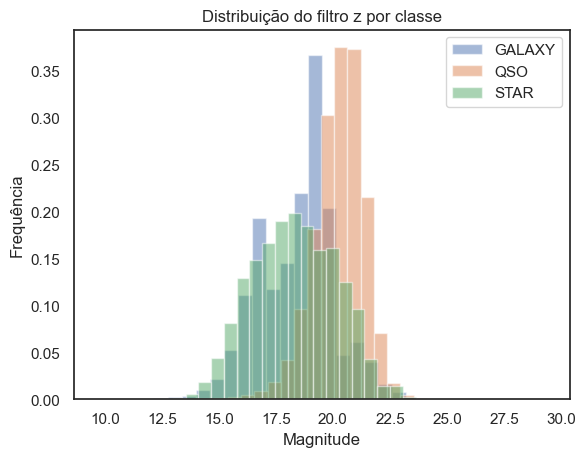

In [94]:
filtros = ["u", "g", "r", "i", "z"]
classes = df["class"].unique()

for filtro in filtros:
    plt.figure()
    
    for classe in classes:
        subset = df[df["class"] == classe]
        plt.hist(subset[filtro], bins=30, alpha=0.5, label=classe, density=True)
        
    plt.title(f"Distribuição do filtro {filtro} por classe")
    plt.xlabel("Magnitude")
    plt.ylabel("Frequência")
    plt.legend()
    plt.show()

In [95]:
# Vemos que existe certa separação entre classes no entanto nenhum filtro isolado separa perfeitamente.
# Provavelmente, a combinação de filtros separará melhor.

# Feature Engeneering

In [96]:
# Definir o dicionário de mapeamento
class_map = {"GALAXY": 0, "STAR": 1, "QSO": 2}

df["class"] = df["class"].str.strip().str.upper()
df["class_encoded"] = df["class"].map(class_map)

print (df['class'].unique())
print (df['class_encoded'].unique())

['GALAXY' 'QSO' 'STAR']
[0 2 1]


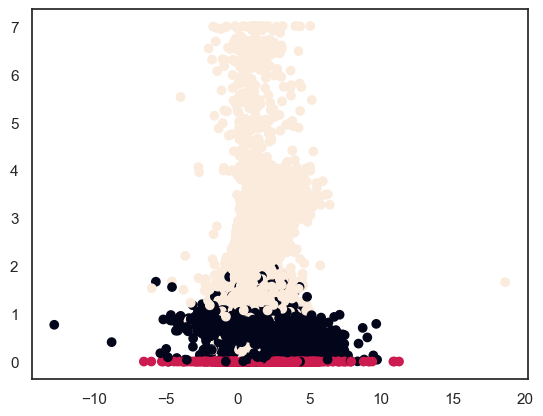

In [98]:
# Vamos criar cores fotométricas para não olhar as features apenas isoladamente.
df["u_g"] = df["u"] - df["g"]
df["g_r"] = df["g"] - df["r"]
df["r_i"] = df["r"] - df["i"]
df["i_z"] = df["i"] - df["z"]

# Vamos analizar a dispersão de uma destas novas variáveis em relação ao redshift 
plt.scatter(df["u_g"], df["redshift"], c=df["class_encoded"])

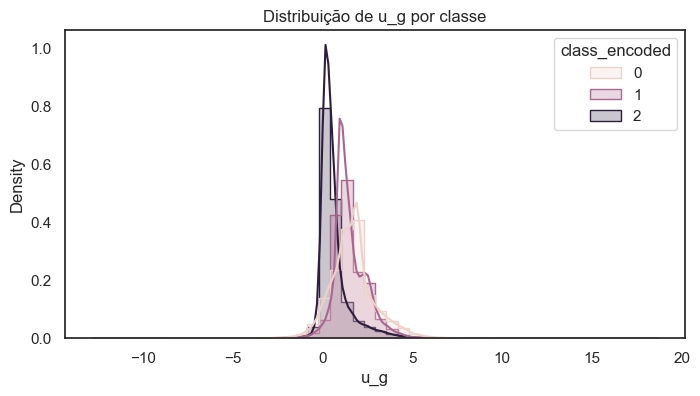

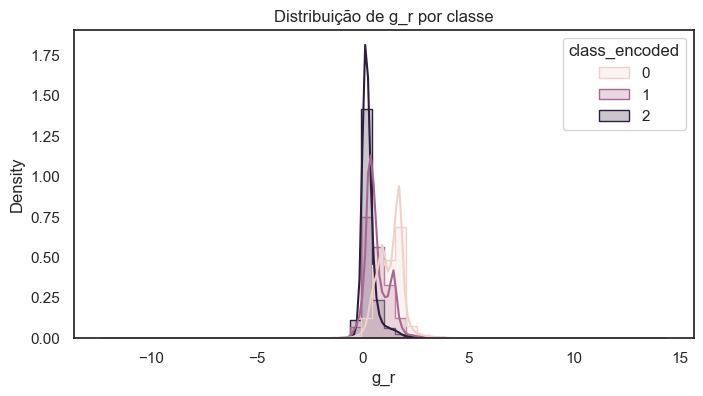

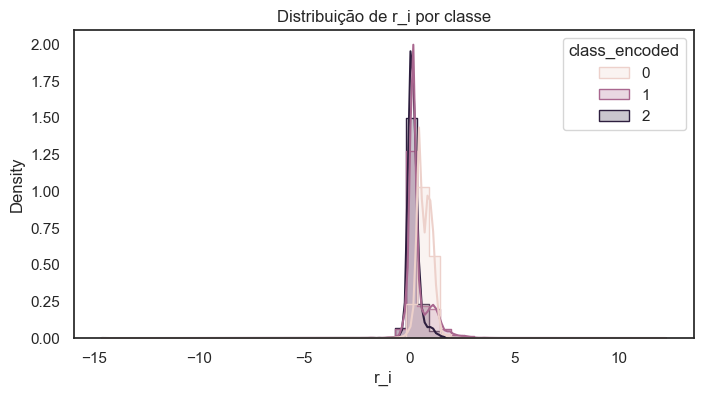

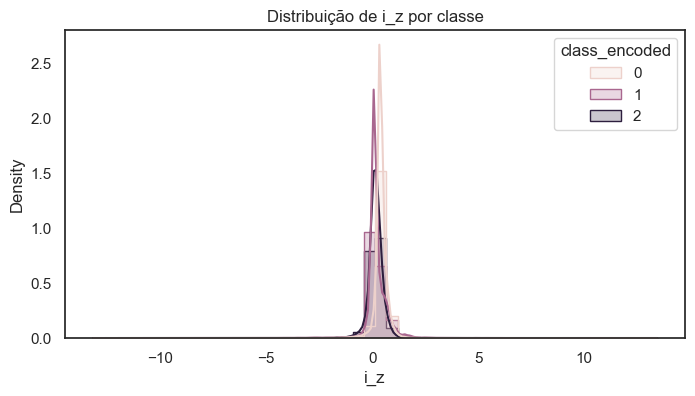

In [99]:
# O scatter mostra que temos três “faixas” principais, ou seja, não é uma única fronteira linear

# Vamos plotar histogramas dessas diferenças separados por classe para medir o quanto o objeto é mais brilhante em determinada feature
# comparado a outra:

colors = ['u_g', 'g_r', 'r_i', 'i_z']

for color in colors:
    plt.figure(figsize=(8,4))
    sns.histplot(
        data=df,
        x=color,
        hue='class_encoded',
        bins=50,
        kde=True,
        element='step',
        stat='density',
        common_norm=False
    )
    plt.title(f'Distribuição de {color} por classe')
    plt.show()

In [100]:
# Podemos entender que os eixos comprimidos vem de poucos valores extremos e não de erro sistêmico


# Análise quantitativa

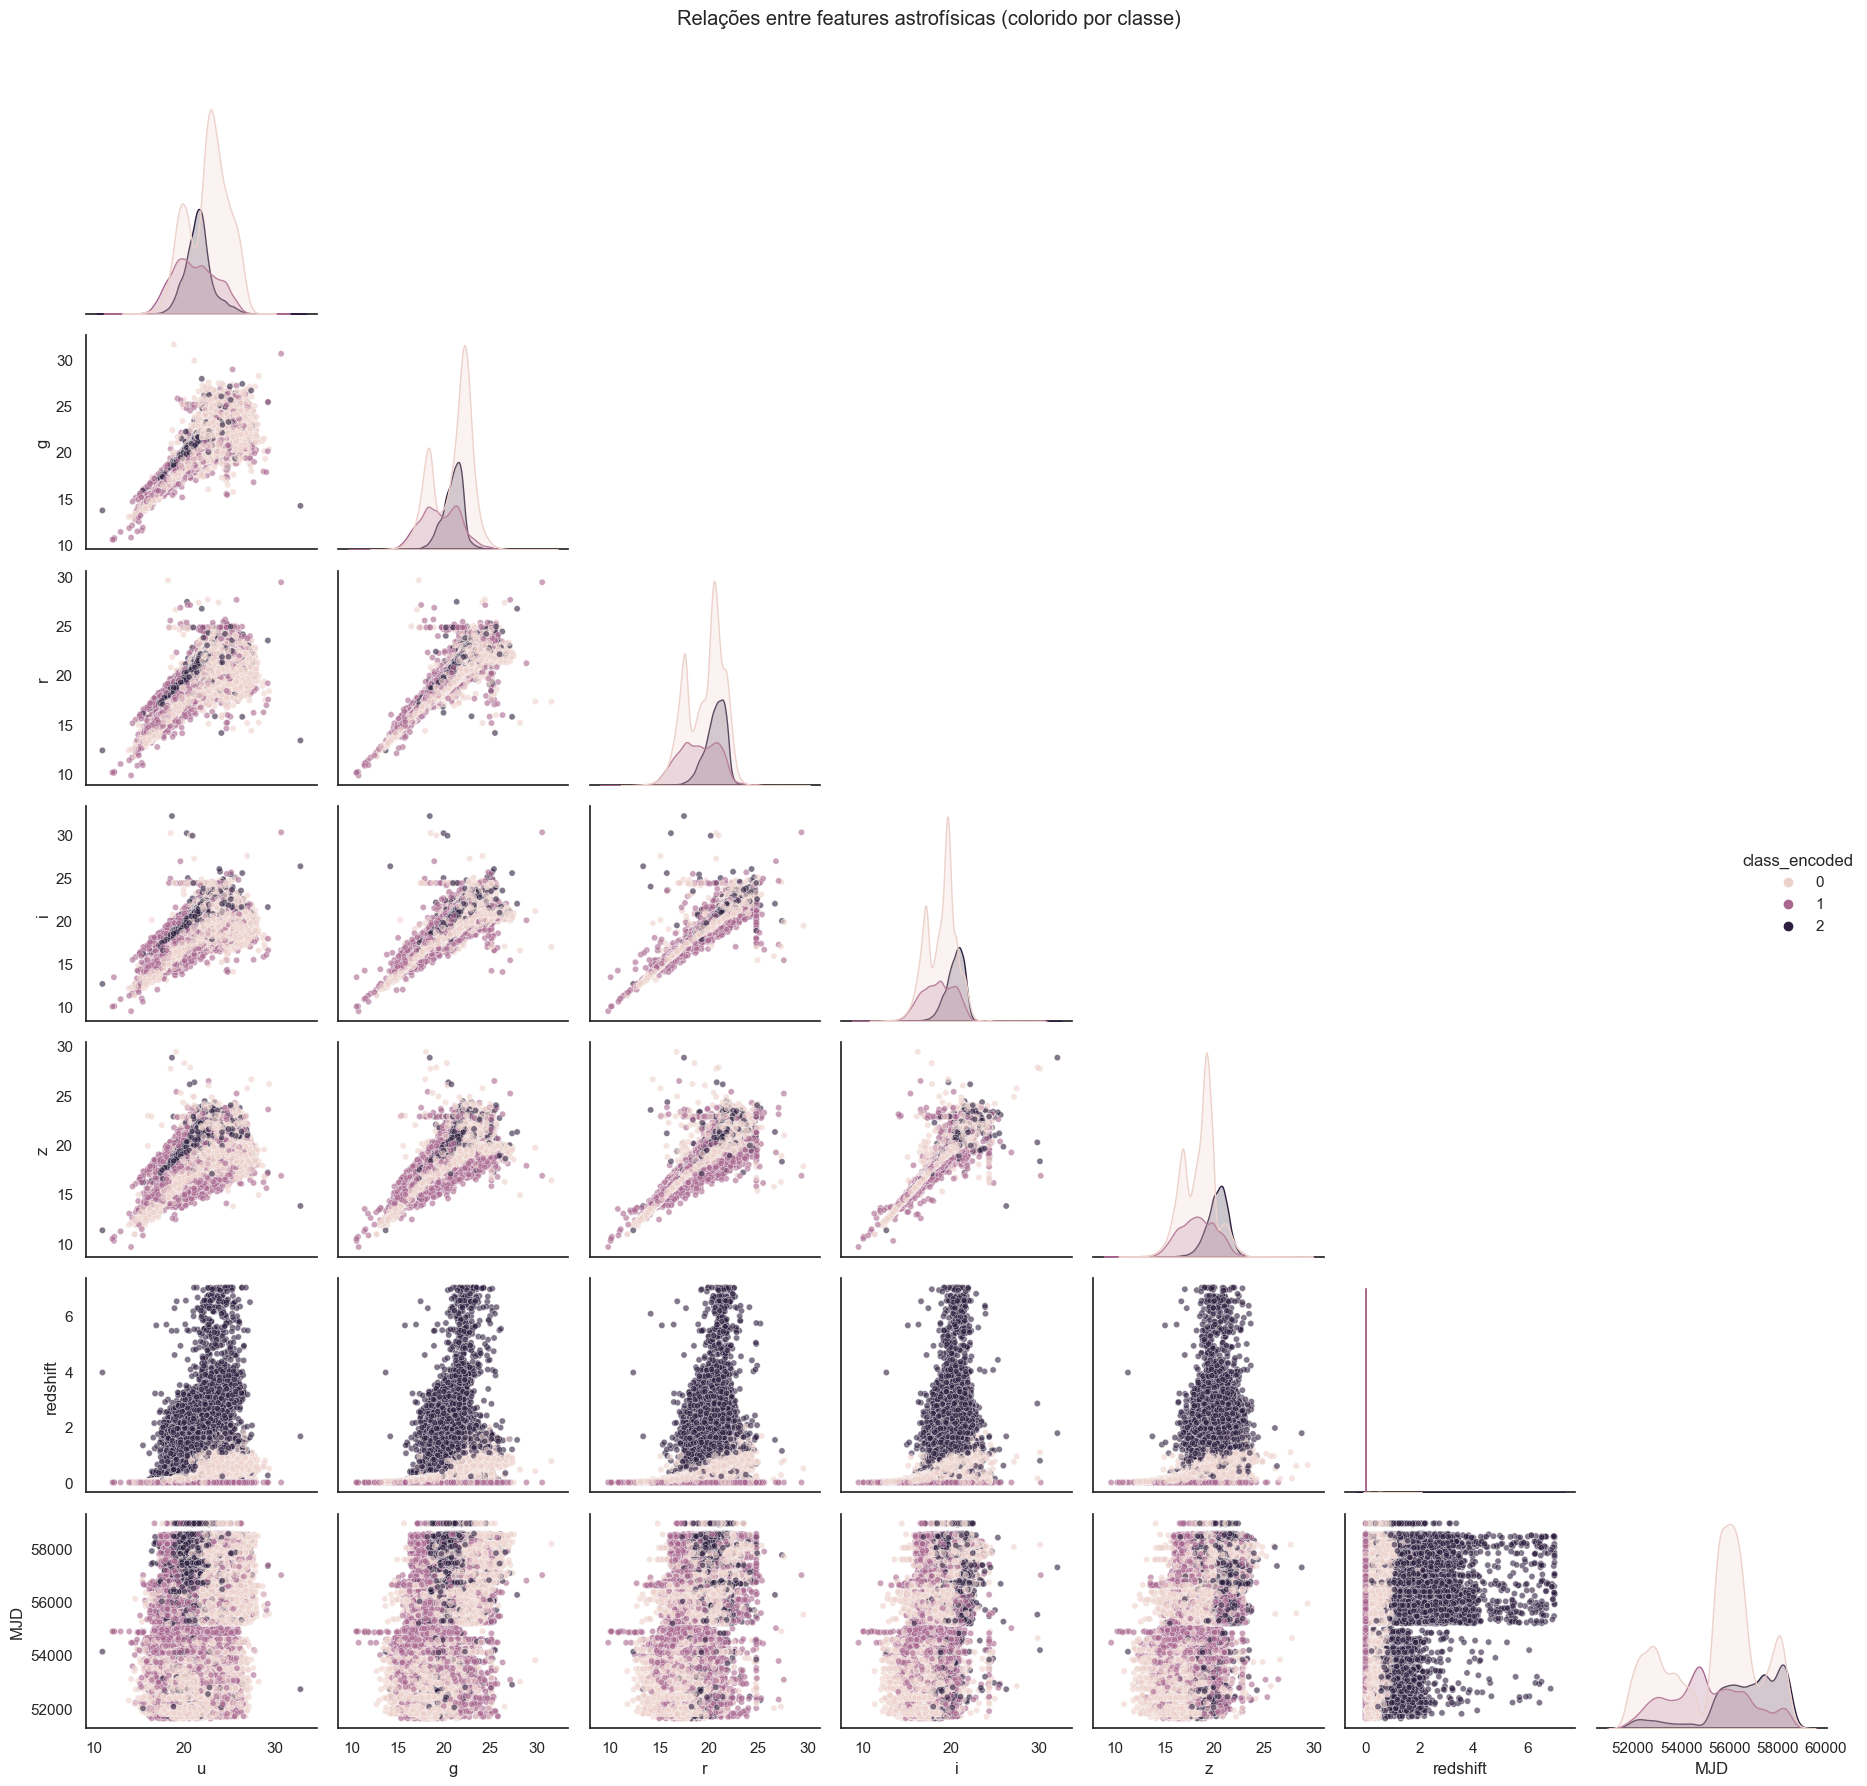

In [101]:
#  Agora vamos entender quais features são significativas 
features = ['u', 'g', 'r', 'i', 'z', 'redshift', 'MJD']

sns.set(style="white", context="notebook")
g = sns.pairplot(
    df[features + ['class_encoded']], 
    hue="class_encoded",
    diag_kind="kde",   # curva de densidade na diagonal
    corner=True,       # mostra só metade inferior (para não repetir)
    plot_kws=dict(s=20, alpha=0.6)  # pontos menores e translúcidos
)

g.fig.suptitle("Relações entre features astrofísicas (colorido por classe)", y=1.02)
plt.tight_layout()
plt.show()

In [102]:
# O pairplot indica que há multicolinearidade forte entre os filtros (u, g, r, i, z)
# O redshift é uma feature que, sozinha, já separa bem os Quasares (QSO)
# MJD não informa o bastante para ser considerado uma feature importante para classificação

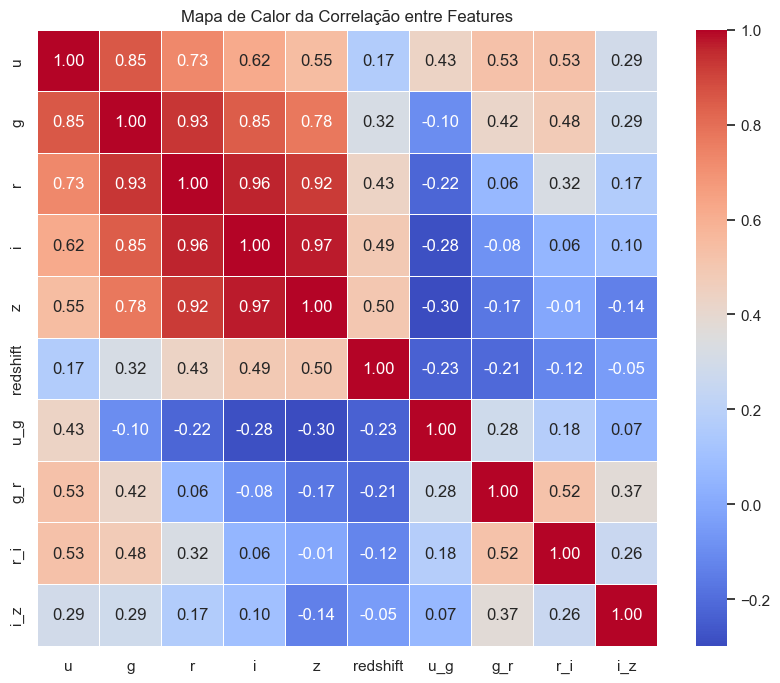

In [103]:
# Vamos analisar quantitativamente pelo mapa de calor

# Separação das features
X = df.drop(columns=["obj_ID","class","alpha", "MJD", "delta", "run_ID", "rerun_ID", "cam_col", "field_ID", "spec_obj_ID", "plate", "fiber_ID",])

# Separação do target
y = df["class"]

colunas_numericas = ['u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']
df_corr = df[colunas_numericas]

# Cálculo da matriz de correlação
matriz_correlacao = df_corr.corr()

# Mapa de Calor
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_correlacao,
    annot=True,          # Mostra os valores de correlação no gráfico
    fmt=".2f",           # Formata os valores com 2 casas decimais
    cmap='coolwarm',     # Define o esquema de cores (bom para visualizar positivo/negativo)
    linewidths=.5,       # Adiciona linhas entre as células
    cbar=True            # Mostra a barra de cores
)
plt.title('Mapa de Calor da Correlação entre Features')
plt.show()

In [104]:
# Reforçamos que existe forte multicolinearidade entre magnitudes, ou seja, essas variáveis estão praticamente carregando
# a mesma informação. 

# Além disso, as cores capturam informação espectral relativa e reduzem redundância, elas carregam informação diferente 
# das magnitudes puras.

# Novamente, quantitativamente, o redshift apresenta associação relevante com magnitudes.


# Tratamento de dados (missing, outliers, escala)

In [105]:
# Verificar NaN
print("NaN por coluna:")
print(X.isna().sum())

# Verificar infinitos
print("\nInf por coluna:")
print(np.isinf(X).sum())

NaN por coluna:
u                0
g                0
r                0
i                0
z                0
redshift         0
class_encoded    0
u_g              0
g_r              0
r_i              0
i_z              0
dtype: int64

Inf por coluna:
u                0
g                0
r                0
i                0
z                0
redshift         0
class_encoded    0
u_g              0
g_r              0
r_i              0
i_z              0
dtype: int64


In [106]:
print(df["class"].isna().sum())
print(df["class"].unique())
print(df["class"].dtype)

0
['GALAXY' 'QSO' 'STAR']
object


# Seleção de features

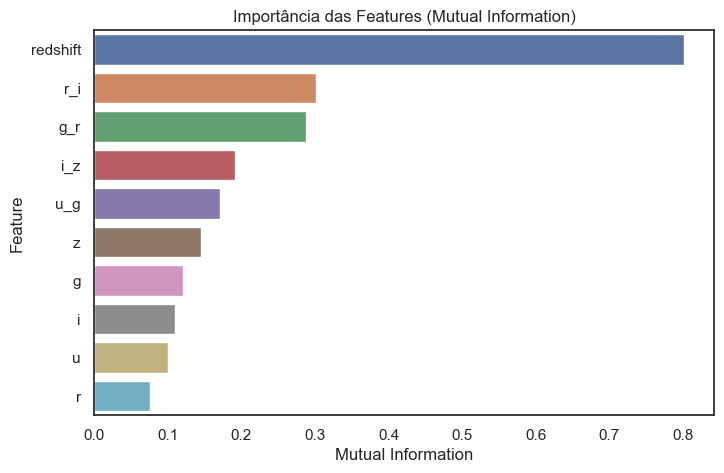

In [109]:
# Visto que nosso problema não é linear, vamos usar o Mutual Information para capturar dependências não lineares com a classe.

from sklearn.feature_selection import mutual_info_classif

features = ['u','g','r','i','z','redshift','u_g','g_r','r_i','i_z']

X = df[features]
y = df['class']

mi_scores = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    'Feature': features,
    'Mutual Information': mi_scores
}).sort_values(by='Mutual Information', ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=mi_df, x='Mutual Information', y='Feature', hue=)
plt.title('Importância das Features (Mutual Information)')
plt.show()

In [ ]:
# Vemos que magnitudes individuais (u, g, r, i, z) têm menos MI, provavelmente pois são altamente correlacionadas entre si

# Já as cores (u_g, g_r, r_i) capturam diferenças espectrais.
# Por isso aparecem acima das magnitudes isoladas.

# Modelagem

In [110]:
from sklearn.model_selection import train_test_split

features = ['u', 'g', 'r', 'i', 'z', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']

X = df[features]
y = df['class_encoded']  

# Split estratificado 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [111]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    max_depth=5,          # controla complexidade
    min_samples_split=20, # evita divisões muito pequenas
    random_state=42
)

modelo.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=20, random_state=42)

# Avaliação do modelo

In [112]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = modelo.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:\n")
print(classification_report(y_test, y_pred))

Acurácia: 0.97575

Relatório de Classificação:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11889
           1       1.00      1.00      1.00      4319
           2       0.96      0.91      0.94      3792

    accuracy                           0.98     20000
   macro avg       0.98      0.97      0.97     20000
weighted avg       0.98      0.98      0.98     20000



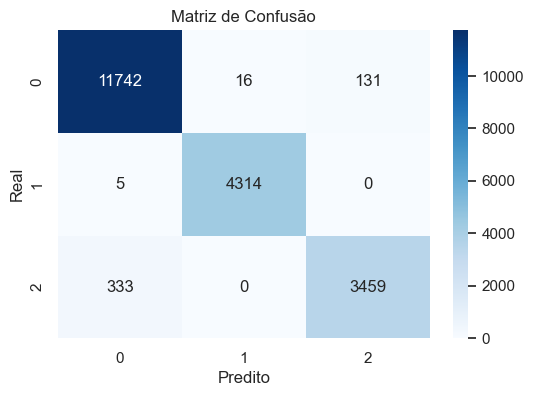

In [113]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão")
plt.show()

In [114]:
# 333 objetos da classe 2 foram classificados como 0
# 131 objetos da classe 0 foram classificados como 2

# Ou seja: A maior confusão ocorre entre GALAXY e QSO.

In [116]:
# Vamos ver a importância das features na árvore:
importancias = pd.Series(modelo.feature_importances_, index=features)
importancias.sort_values(ascending=False)

redshift    0.931651
g_r         0.042983
r           0.012153
g           0.008426
r_i         0.004091
i           0.000497
i_z         0.000146
u_g         0.000043
z           0.000010
u           0.000000
dtype: float64

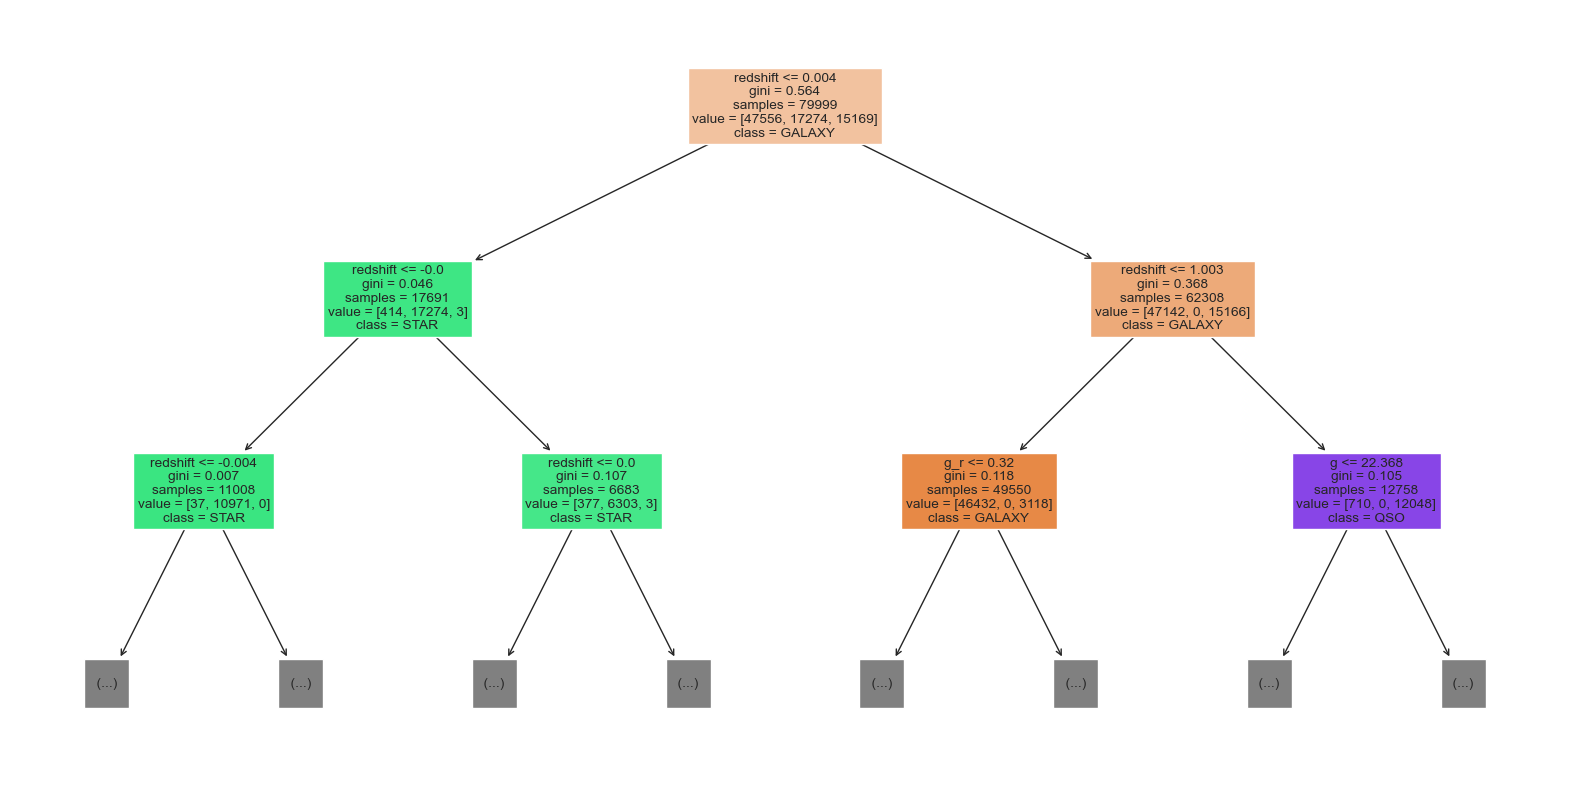

In [123]:
# Redshift está sendo muito determinante para a árvore, por isso a performance foi boa

# Vamos confirmar visualizando a árvore
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(
    modelo,
    feature_names=features,
    class_names=["GALAXY","STAR","QSO"],
    filled=True,
    max_depth=2  # limita a profundidade exibida
)
plt.show()

In [125]:
# Vamos fazer um modelo sem redshift

features_sem_redshift = [f for f in features if f != "redshift"]

X2 = df[features_sem_redshift]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model2 = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=50,
    random_state=42
)

model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("Acurácia sem redshift:", accuracy_score(y_test2, y_pred2))
print("\nRelatório sem redshift:\n")
print(classification_report(y_test2, y_pred2))

Acurácia sem redshift: 0.8193

Relatório sem redshift:

              precision    recall  f1-score   support

           0       0.84      0.94      0.89     11889
           1       0.74      0.57      0.64      4319
           2       0.80      0.72      0.76      3792

    accuracy                           0.82     20000
   macro avg       0.80      0.74      0.76     20000
weighted avg       0.81      0.82      0.81     20000



In [126]:
# O redshift carrega a maior parte da informação discriminativa, especialmente para QSO.
# Como queremos o melhor classificador possível, vamos seguir com essa feature.

# Agora, a dúvida é se o modelo está generalizando ou apenas memorizando?

In [128]:
print("Acurácia treino:", modelo.score(X_train, y_train))
print("Acurácia teste:", modelo.score(X_test, y_test))

Acurácia treino: 0.9737746721834023
Acurácia teste: 0.97575


In [132]:
# Vamos fazer uma validação cruzada para verificar se o modelo continua performando bem
from sklearn.model_selection import cross_val_score

scores = cross_val_score(modelo, X, y, cv=5)
print("CV média:", scores.mean())
print("CV desvio:", scores.std())

CV média: 0.9734797309865494
CV desvio: 0.0005037903727697166


# Conclusão

In [130]:
# O redshift é a variável mais informativa

# A árvore atinge ~97.5% de acurácia

# Não há evidência de overfitting (treino ≈ teste)

# Sem redshift a performance cai para ~82%, indicando forte dependência física dessa variável